In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Medicaldataset.csv")

In [3]:
data.head(10)

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,63,1,66,160,83,160.0,1.80,0.012,negative
1,20,1,94,98,46,296.0,6.75,1.060,positive
2,56,1,64,160,77,270.0,1.99,0.003,negative
3,66,1,70,120,55,270.0,13.87,0.122,positive
4,54,1,64,112,65,300.0,1.08,0.003,negative
5,52,0,61,112,58,87.0,1.83,0.004,negative
6,38,0,40,179,68,102.0,0.71,0.003,negative
7,61,1,60,214,82,87.0,300.00,2.370,positive
8,49,0,60,154,81,135.0,2.35,0.004,negative
9,65,1,61,160,95,100.0,2.84,0.011,negative


In [4]:
data.isnull().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

In [5]:
data.shape

(1319, 9)

In [6]:
data.columns

Index(['Age', 'Gender', 'Heart rate', 'Systolic blood pressure',
       'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin',
       'Result'],
      dtype='object')

In [7]:
data.select_dtypes(['object']).columns

Index(['Result'], dtype='object')

In [8]:
data.select_dtypes(['float']).columns

Index(['Blood sugar', 'CK-MB', 'Troponin'], dtype='object')

In [9]:
from sklearn.preprocessing import OneHotEncoder

In [10]:
from sklearn.preprocessing import LabelEncoder

# EDA Analysis

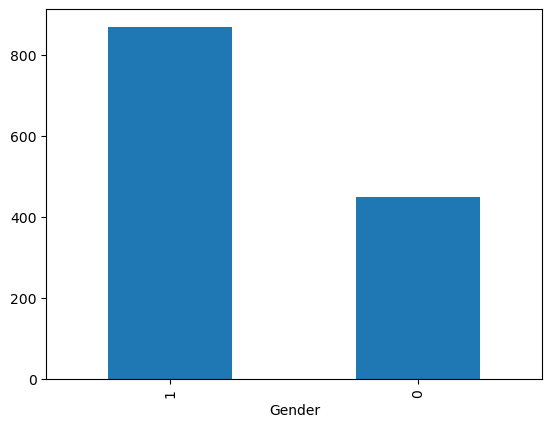

In [11]:
data['Gender'].value_counts().plot(kind = 'bar')
plt.xlabel = "Gender"
plt.ylabel= "count"
plt.show()

In [12]:
label_encoder = LabelEncoder()
data['Result'] = label_encoder.fit_transform(data['Result'])


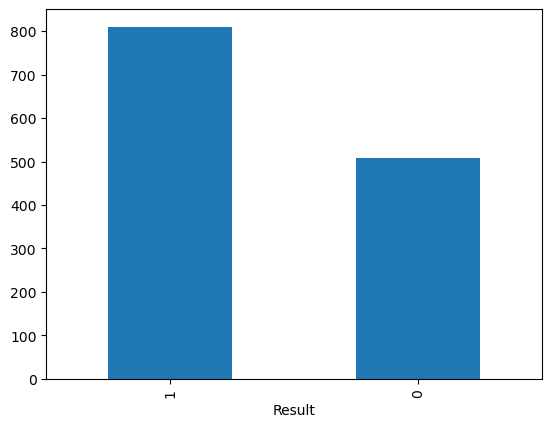

In [13]:
data['Result'].value_counts().plot(kind = 'bar')
plt.xlabel = "Result"
plt.ylabel= "count"
plt.show()

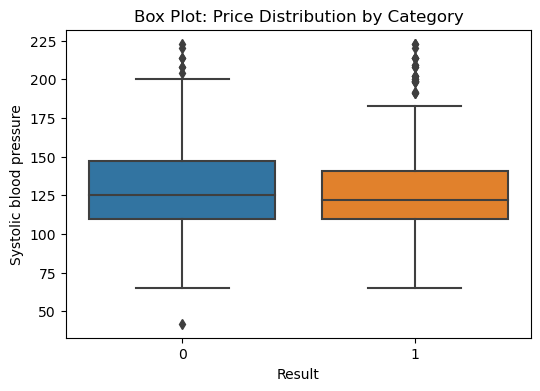

In [14]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['Result'], y=data['Systolic blood pressure'])
plt.title("Box Plot: Price Distribution by Category")
plt.show()

In [15]:
target = 'Result'
X = data.drop(columns=[target])
y = data[target]

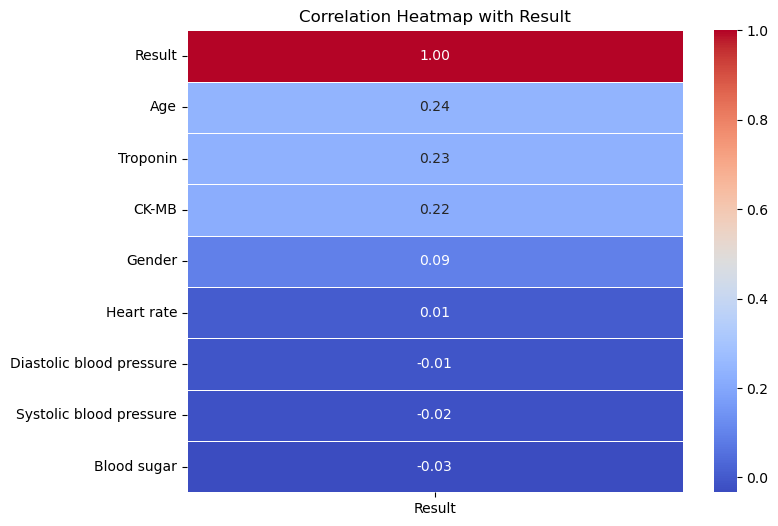

In [16]:
corr_matrix = data.corr()

target_corr = corr_matrix[[target]].sort_values(by=target, ascending=False)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(target_corr, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")

plt.title(f"Correlation Heatmap with {target}")
plt.show()

In [17]:
data.columns

Index(['Age', 'Gender', 'Heart rate', 'Systolic blood pressure',
       'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin',
       'Result'],
      dtype='object')

# Feature Selection

In [18]:
X = data[["CK-MB", "Troponin", "Age"]]
Y = data['Result']

In [19]:
X

,CK-MB,Troponin,Age
0,1.80,0.012,63
1,6.75,1.060,20
2,1.99,0.003,56
3,13.87,0.122,66
4,1.08,0.003,54
...,...,...,...
1314,1.63,0.006,44
1315,1.33,0.172,66
1316,1.24,4.250,45
1317,5.80,0.359,54


In [20]:
Z = data[["CK-MB", "Troponin", "Age","Result"]]
Z

,CK-MB,Troponin,Age,Result
0,1.80,0.012,63,0
1,6.75,1.060,20,1
2,1.99,0.003,56,0
3,13.87,0.122,66,1
4,1.08,0.003,54,0
...,...,...,...,...
1314,1.63,0.006,44,0
1315,1.33,0.172,66,1
1316,1.24,4.250,45,1
1317,5.80,0.359,54,1


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
pip uninstall scikit-learn -y

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\dlali\anaconda3\Lib\site-packages\pip\_internal\cli\base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "C:\Users\dlali\anaconda3\Lib\site-packages\pip\_internal\commands\uninstall.py", line 110, in run
    uninstall_pathset.commit()
  File "C:\Users\dlali\anaconda3\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 432, in commit
    self._moved_paths.commit()
  File "C:\Users\dlali\anaconda3\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 278, in commit
    save_dir.cleanup()
  File "C:\Users\dlali\anaconda3\Lib\site-packages\pip\_internal\utils\temp_dir.py", line 173, in cleanup
    rmtree(self._path)
  File "C:\Users\dlali\anaconda3\Lib\site-packages\pip\_vendor\tenacity\__init__.py", line 291, in wrapped_f
    return self(f, *args, **kw)
           ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\dlali\anaconda3\Lib\site-packages\pip\_vend

In [23]:
pip install "scikit-learn>=1.4.0,<1.6.0"

  Obtaining dependency information for scikit-learn<1.6.0,>=1.4.0 from https://files.pythonhosted.org/packages/17/1c/ccdd103cfcc9435a18819856fbbe0c20b8fa60bfc3343580de4be13f0668/scikit_learn-1.5.2-cp311-cp311-win_amd64.whl.metadata
  Using cached scikit_learn-1.5.2-cp311-cp311-win_amd64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp311-cp311-win_amd64.whl (11.0 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.5.2 which is incompatible.


In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

In [27]:
model.fit(x_train,y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [28]:
y_pred = model.predict(x_test)

In [29]:
y_pred

array([1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,

In [30]:
accuracy = model.score(x_test, y_test)
print(f"Accuracy of the Randomforest model: {accuracy}")

Accuracy of the Randomforest model: 0.9772727272727273


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = model.predict(x_test)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Detailed Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[159   1]
 [  8 228]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       160
           1       1.00      0.97      0.98       236

    accuracy                           0.98       396
   macro avg       0.97      0.98      0.98       396
weighted avg       0.98      0.98      0.98       396



In [32]:
import pickle

In [33]:
pickle.dump(model, open('model.pkl','wb'))

# Loading model to compare the results
model = pickle.load(open('model.pkl','rb'))

In [34]:
model.predict([[1.99,0.003,56]])

C:\Users\dlali\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

In [35]:
import os
print(os.path.abspath('model.pkl'))

C:\Users\dlali\model.pkl
